# Use pandas_dataframe_agent for Data Analysis and Data Visualization

In [1]:
# You can use this section to suppress warnings generated by your code:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

from langchain_openai import ChatOpenAI

from langchain_experimental.agents.agent_toolkits import create_pandas_dataframe_agent

# import matplotlib.pyplot as plt
import pandas as pd

In [28]:
llm = ChatOpenAI(model='gpt-4o')

## Load the data set

In [19]:
df = pd.read_csv("./student-matrix.csv")

In [20]:
df.head()

,Unnamed: 0,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  395 non-null    int64 
 1   school      395 non-null    object
 2   sex         395 non-null    object
 3   age         395 non-null    int64 
 4   address     395 non-null    object
 5   famsize     395 non-null    object
 6   Pstatus     395 non-null    object
 7   Medu        395 non-null    int64 
 8   Fedu        395 non-null    int64 
 9   Mjob        395 non-null    object
 10  Fjob        395 non-null    object
 11  reason      395 non-null    object
 12  guardian    395 non-null    object
 13  traveltime  395 non-null    int64 
 14  studytime   395 non-null    int64 
 15  failures    395 non-null    int64 
 16  schoolsup   395 non-null    object
 17  famsup      395 non-null    object
 18  paid        395 non-null    object
 19  activities  395 non-null    object
 20  nursery   

## Create Agent

In [ ]:
agent = create_pandas_dataframe_agent(
    llm,
    df,
    verbose=False,
    return_intermediate_steps=True,  # set return_intermediate_steps=True so that model could return code that it comes up with to generate the chart/response
    handle_parsing_errors=True,
    allow_dangerous_code=True, # Allowing this, because this agent use python-repl to execute python code. It could be dangerous, because It can call any python function behind the hood and could send response to provider.
)

## Query to agent

In [30]:
response = agent.invoke("Find total number of rows in dataframe?")

In [31]:
response['output']

'The total number of rows in the dataframe is 395.'

In [32]:
response

{'input': 'Find total number of rows in dataframe?',
 'output': 'The total number of rows in the dataframe is 395.',
 'intermediate_steps': [(AgentAction(tool='python_repl_ast', tool_input='len(df)', log='Thought: To find the total number of rows in the dataframe, I can use the `len()` function on the dataframe.\nAction: python_repl_ast\nAction Input: len(df)'),
   395)]}

In [ ]:
response['intermediate_steps'][-1][0].tool_input.replace('; ', '\n') # Function that llm used to find response

'len(df)'

In [36]:
len(df)

395

## Another query to agent

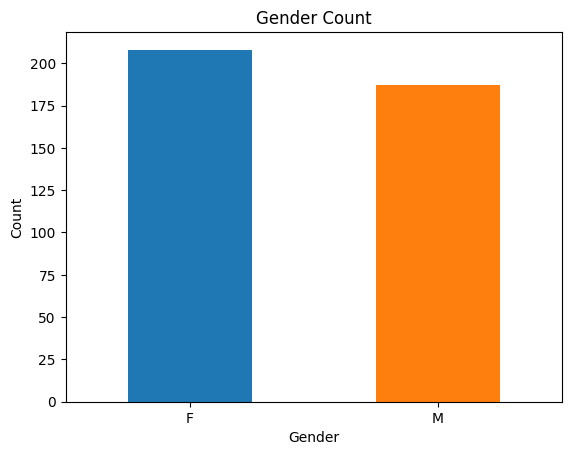

In [37]:
response = agent.invoke("Generate a bar chart to plot the gender count.")

In [39]:
response

{'input': 'Generate a bar chart to plot the gender count.',
 'output': 'A bar chart displaying the gender count has been generated using matplotlib.',
 'intermediate_steps': [(AgentAction(tool='python_repl_ast', tool_input="```python\nimport matplotlib.pyplot as plt\n\n# Count the occurrences of each gender\ngender_counts = df['sex'].value_counts()\n\n# Generate a bar chart\ngender_counts.plot(kind='bar', color=['#1f77b4', '#ff7f0e'])\nplt.title('Gender Count')\nplt.xlabel('Gender')\nplt.ylabel('Count')\nplt.xticks(rotation=0)  # Rotate x labels if needed\nplt.show()\n```", log="Thought: To generate a bar chart for the gender count, I will first compute the count of each gender in the dataframe. Then, I will use matplotlib to create a bar chart to represent this data.\n\nAction: python_repl_ast\nAction Input: \n```python\nimport matplotlib.pyplot as plt\n\n# Count the occurrences of each gender\ngender_counts = df['sex'].value_counts()\n\n# Generate a bar chart\ngender_counts.plot(kind

In [42]:
response['output']

'A bar chart displaying the gender count has been generated using matplotlib.'

In [41]:
print(response['intermediate_steps'][-1][0].tool_input.replace('; ', '\n')) # Function that llm used to find response

```python
import matplotlib.pyplot as plt

# Count the occurrences of each gender
gender_counts = df['sex'].value_counts()

# Generate a bar chart
gender_counts.plot(kind='bar', color=['#1f77b4', '#ff7f0e'])
plt.title('Gender Count')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)  # Rotate x labels if needed
plt.show()
```


## Anther query

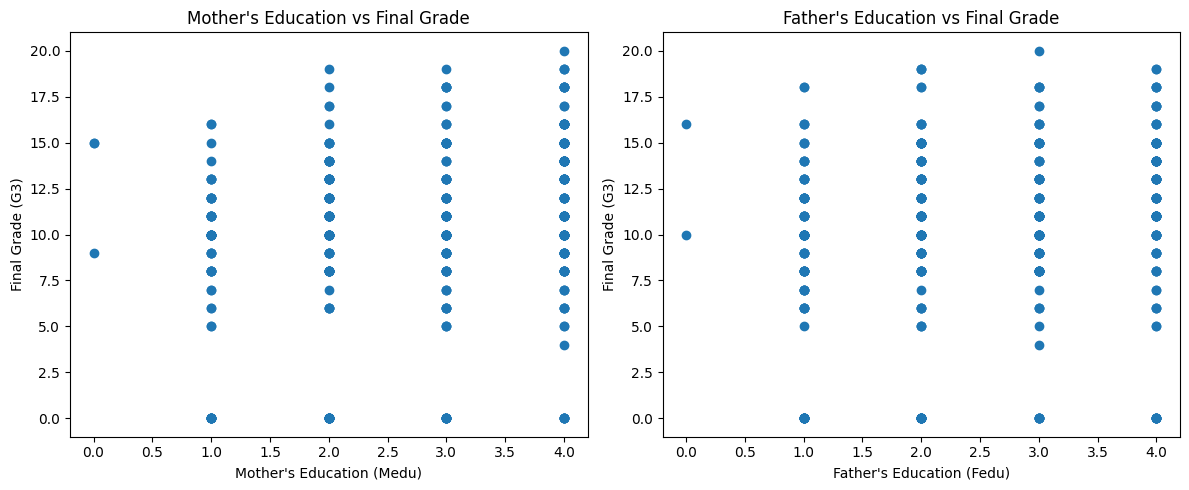

In [43]:
response = agent.invoke(
    "Generate scatter plots showing the relationship between "
    "'Medu' (mother's education level) and 'G3' (final grade), "
    "and between 'Fedu' (father's education level) and 'G3'. "
    
)